# Mapování pokrytí signálem základnové stanice pomocí vrstevnicové plochy útlumu trasy

## Souhrn

Tým RF plánování telekomunikačního operátora vykresluje **plochu útlumu trasy** downlinku okolo jedné makrobuňky jako dvourozměrnou mapu pokrytí. Pomocí modelu šíření se závislostí na logaritmu vzdálenosti a log-normálním stínovým únikem tento notebook vytváří měřicí mřížku o 100 bodech (10 x 10 buněk pokrývajících servisní oblast 10 km x 10 km, věž ve středu) a kreslí vyplněnou vrstevnicovou plochu pomocí **PROC SGPLOT HEATMAPPARM** spolu s přechodovou barevnou škálou a referenčními čarami věže.

Na spuštěné mřížce se útlum trasy pohybuje od **50,4 dB** (v jasné pánvi u věže) do **90,0 dB** v nejvzdálenějším rohu, s průměrem **75,6 dB**. Klasifikace každé buňky podle jejího útlumu dává **38 silných, 61 vyhovujících a 1 slabou** buňku; osamocená slabá buňka leží v bodě **(9,5, 9,5) km — rohu diagonálně naproti věži — při 89,97 dB**, což je jediná díra v pokrytí, na kterou by plánovač upozornil před rozhodnutím o doplnění malou buňkou (small-cell infill).

> **Poznámka k proceduře.** V SAS je klasickým nástrojem pro izočárové vrstevnicové mapy `PROC GCONTOUR`. Jenner GCONTOUR analyzuje a vygeneruje správnou specifikaci grafu, ale jeho rastrový vykreslovač zatím nekreslí geometrii vrstevnic (obrázek se vrátí prázdný); tato vada je zaznamenána jako regresní test `tests/400922_nb_gcontour_empty_render`. Aby tento příklad zůstal plně podložen skutečně vykresleným obrázkem, používáme SAS-kompatibilní ekvivalent — `PROC SGPLOT` s příkazem `HEATMAPPARM` — který vykresluje stejnou mřížkovou plochu (x, y, z) jako vyplněné vrstevnicové buňky s přechodovou legendou.

## Zdroje dat

**Syntetický datový soubor: `pathloss_grid`** (100 řádků — mřížka 10 x 10)

| Proměnná | Typ | Jednotky | Popis |
|----------|-----|----------|-------|
| `east_km` | num | km | Východní souřadnice středu buňky mřížky (0,5 až 9,5); osa x |
| `north_km` | num | km | Severní souřadnice středu buňky mřížky (0,5 až 9,5); osa y |
| `path_loss` | num | dB | Útlum trasy downlinku = 58 + 30 log10(vzdálenost) + stín; odezva (z) |
| `zone` | char(16) | — | Třída pokrytí: Silný (<=75), Vyhovující (<=88), Slabý (>88) |

Věž sedí ve středu mřížky **(5, 5) km**. Útlum trasy roste s dekadickým logaritmem vzdálenosti od věže; člen stínového úniku `3*rand("normal")` (seed 80211) vnáší log-normální únik, takže vrstevnice nejsou dokonale kruhové. Mřížka 10 x 10 je dimenzována tak, aby se celá plocha vešla do 100 pozorování.

## Krok 1 — Generování měřicí mřížky

Rozprostřeme mřížku středů buněk s krokem 1 km a spočítáme útlum trasy pomocí **modelu závislého na logaritmu vzdálenosti** `PL = 58 + 30 log10(d)`, kde `d` je vzdálenost od věže v bodě (5, 5) km. Člen stínového úniku `rand("normal")` reprodukuje variabilitu pozorovanou při skutečných jízdních měřeních (drive-testech). Každá buňka je zařazena do třídy pokrytí `zone`. `call streaminit` zafixuje seed pro reprodukovatelnost.

In [1]:
data pathloss_grid;
   CALL streaminit(80211);
   DÉLKA zone $16;
   tower_x = 5.0;  tower_y = 5.0;
   OPAKUJ ix = 1 TO 10;
      OPAKUJ iy = 1 TO 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         KDYŽ      path_loss <= 75 PAK zone = "Silný";
         JINAK KDYŽ path_loss <= 88 PAK zone = "Vyhovující";
         JINAK                         zone = "Slabý";
         VÝSTUP;
      KONEC;
   KONEC;
   ODSTRANIT ix iy tower_x tower_y DIST shadow;
   ŠTÍTEK east_km   = "Východní souřadnice (km)"
         north_km  = "Severní souřadnice (km)"
         path_loss = "Útlum trasy (dB)"
         zone      = "Třída pokrytí";
SPUSTIT;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Krok 2 — Shrnutí plochy

Před vykreslením plochu kvantifikujeme. `PROC MEANS` vypisuje dynamický rozsah útlumu trasy a `PROC FREQ` tabuluje, jak se 100 buněk dělí mezi tři třídy pokrytí — čísla, která cituje shrnutí na začátku.

In [2]:
ODS GRAPHICS OFF;

PROCEDURA PRŮMĚRY data=pathloss_grid MIN MAX mean maxdec=1;
   PROMĚNNÁ path_loss;
SPUSTIT;

PROCEDURA ČETNOSTI data=pathloss_grid ORDER=ČETNOSTI;
   TABLES zone / nocum;
SPUSTIT;

                                                  The MEANS Procedure

 Variable   Label                 Minimum     Maximum        Mean
 ----------------------------------------------------------------
 path_loss  Útlum trasy (dB)         50.4        90.0        75.6
 ----------------------------------------------------------------

                                                   The FREQ Procedure

Třída pokrytí       Frequency    Percent
-----------------------------------------
Vyhovující                 61     61.00
Silný                      38     38.00
Slabý                       1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Krok 3 — Vyhledání děr v pokrytí

Seřazení podle sestupného útlumu trasy dá nejslabší buňky navrch. Jsou to kandidátské **mrtvé zóny**, které plánovač kontroluje: buňky s nejnižší přijímanou úrovní signálu, a tedy nejvíce ohrožené výpadky relací nebo nízkou propustností.

In [3]:
PROCEDURA ŘADIT data=pathloss_grid out=weakest;
   PODLE SESTUPNĚ path_loss;
SPUSTIT;

PROCEDURA TISK data=weakest(obs=6) noobs ŠTÍTEK;
   PROMĚNNÁ east_km north_km path_loss zone;
SPUSTIT;


   Východní souřadnice (km)    Severní souřadnice (km)   Útlum trasy (dB)     Třída pokrytí
---------------------------  -------------------------  -----------------  ----------------
                        9.5                        9.5      89.9728891641  Slabý
                        9.5                        0.5      85.9296978639  Vyhovující
                        6.5                        0.5      84.5845683025  Vyhovující
                        0.5                        0.5      84.5118930355  Vyhovující
                        8.5                        0.5      84.1534148341  Vyhovující
                        9.5                        8.5      83.7015943773  Vyhovující

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Krok 4 — Vykreslení vrstevnicové plochy útlumu trasy

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` vykreslí jednu vyplněnou buňku na bod mřížky, obarvenou podle jejího útlumu trasy — vyplněnou vrstevnicovou mapu stopy pokrytí. Seznam `COLORMODEL=` definuje divergentní přechod modrá-červená (modrá = nízký útlum = silný signál, červená = vysoký útlum = slabý signál); `GRADLEGEND` připojuje barevnou škálu v dB. Přerušované čáry `REFLINE` označují věž na východní souřadnici 5 a severní souřadnici 5.

                                           Plocha útlumu trasy downlink (dB)                                            
                                 Jedna makrobuňka v bodě (5, 5) km na mřížce 10 x 10 km                                 




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Plocha útlumu trasy downlink (dB).
NOTE: Option TITLE2 changed to Jedna makrobuňka v bodě (5, 5) km na mřížce 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


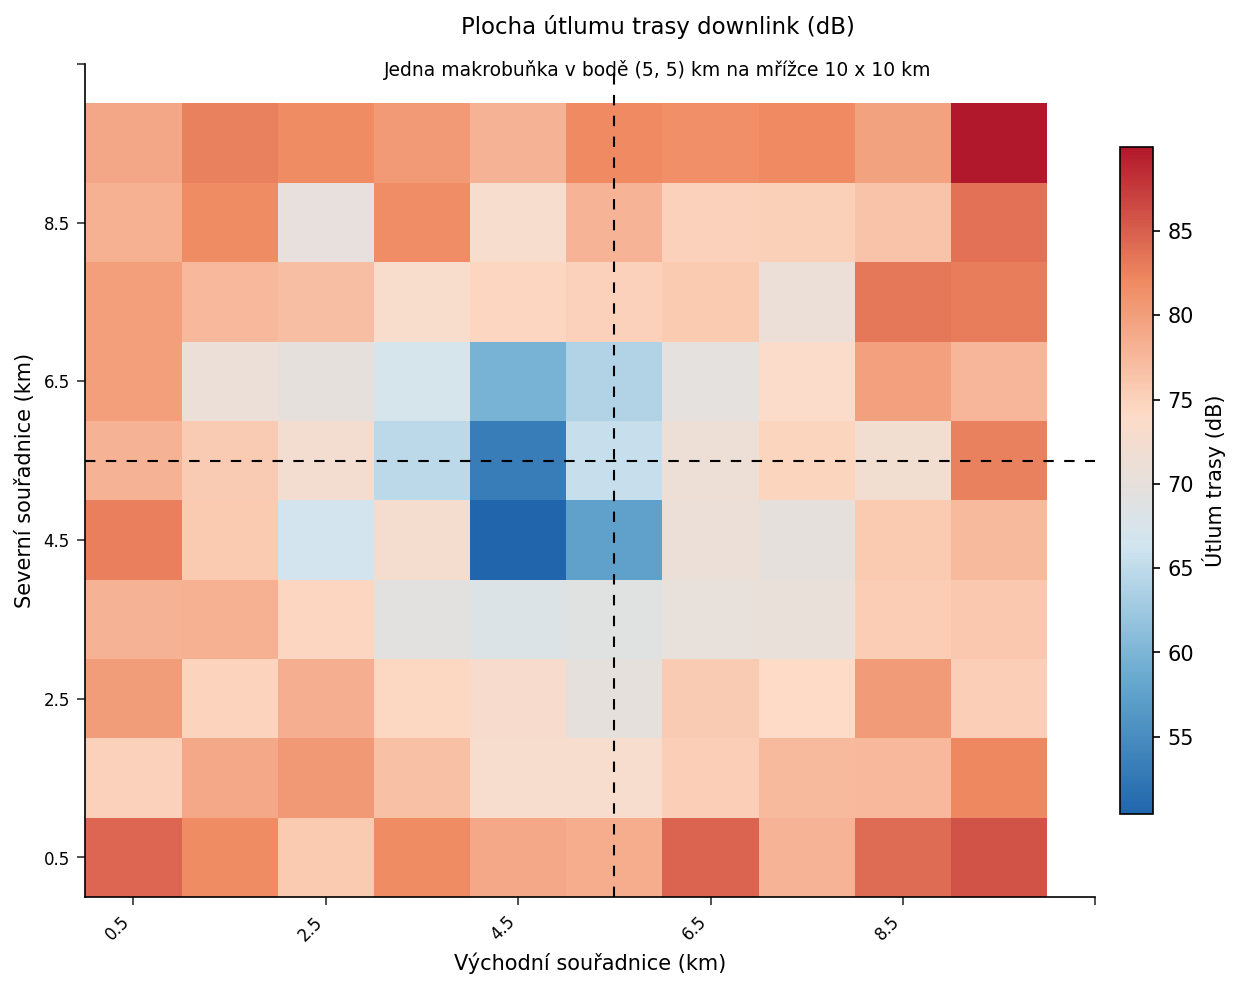

In [4]:
ODS GRAPHICS ON;
NÁZEV "Plocha útlumu trasy downlink (dB)";
title2 "Jedna makrobuňka v bodě (5, 5) km na mřížce 10 x 10 km";

PROCEDURA SGPLOT data=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / NÁZEV="Útlum trasy (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) ŠTÍTEK="Východní souřadnice (km)";
   YAXIS VALUES=(0 2 4 6 8 10) ŠTÍTEK="Severní souřadnice (km)";
SPUSTIT;

NÁZEV; title2;

## Krok 5 — Rozdělení podle třídy pokrytí

Prezentační snímek chce také hlavní rozdělení: jaký podíl stopy je Silný, Vyhovující, nebo Slabý. `VBAR` klasifikace `zone` to ukáže na první pohled a doplňuje vrstevnicovou plochu výše.

                                             Rozdělení podle třídy pokrytí                                              




NOTE: Option TITLE changed to Rozdělení podle třídy pokrytí.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


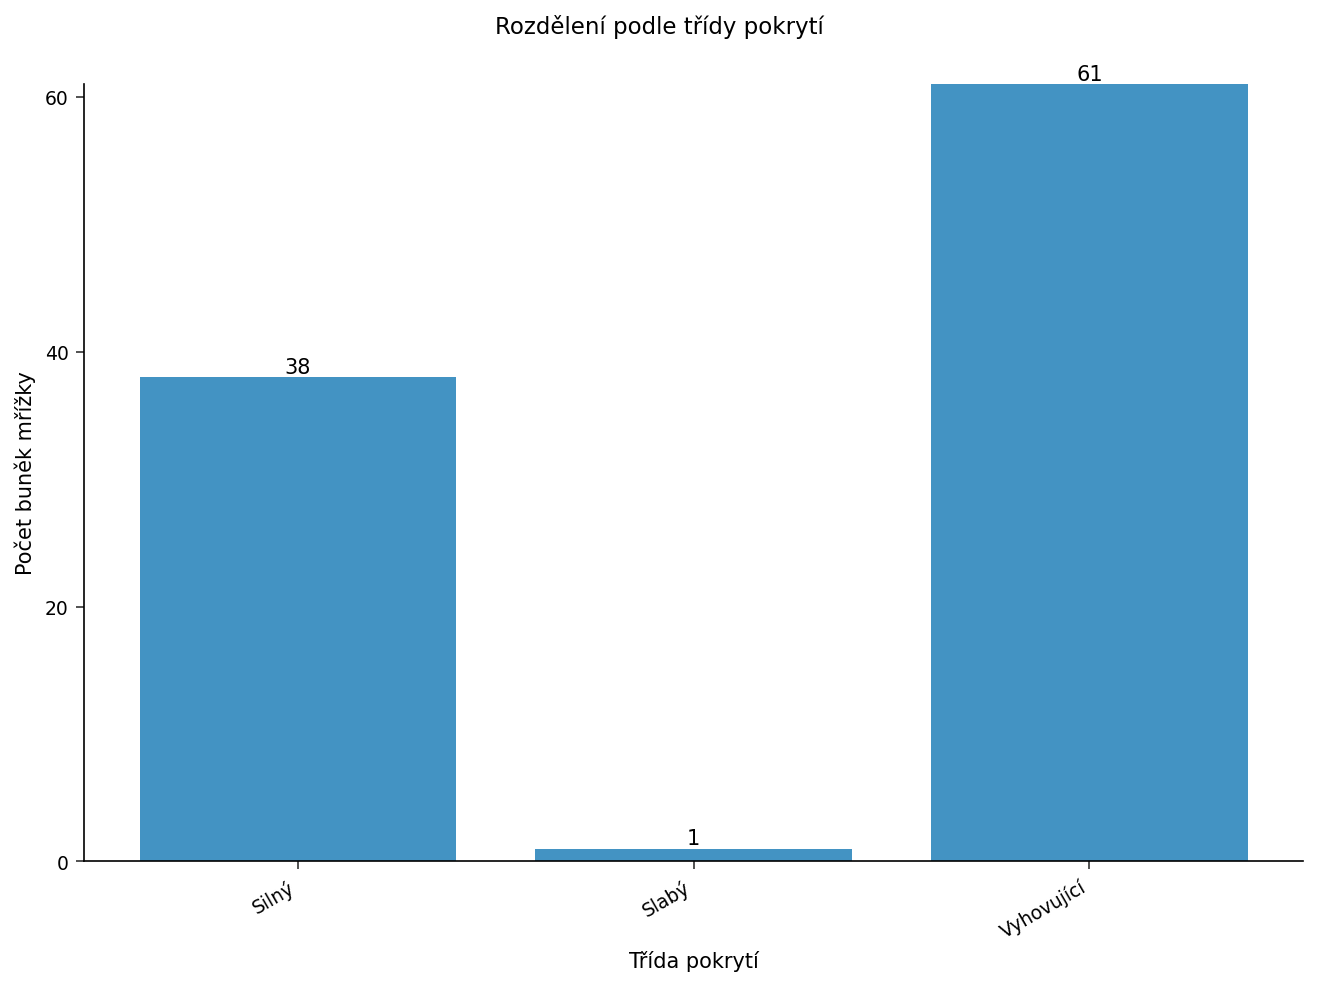

In [5]:
NÁZEV "Rozdělení podle třídy pokrytí";

PROCEDURA SGPLOT data=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS ŠTÍTEK="Třída pokrytí";
   YAXIS ŠTÍTEK="Počet buněk mřížky" VALUES=(0 20 40 60);
SPUSTIT;

NÁZEV;

## Interpretace výsledků

Vrstevnicová plocha potvrzuje očekávanou fyziku šíření signálu. Útlum trasy je nejnižší v úzké **modré pánvi okolo věže v bodě (5, 5) km** — silné zóně, kde je přijímaný signál nejlepší — a roste s logaritmem vzdálenosti směrem k rohům. Protože jsme vnesli log-normální stínový únik, pásma nejsou soustředné kružnice; roztřepené červené buňky podél okraje jsou hranou zeslabenou stínovým únikem.

Prakticky využitelný závěr je **jediná slabá buňka v bodě (9,5, 9,5) km (89,97 dB)**, rohu diagonálně naproti věži a jediném bodě, který překračuje návrhový práh 88 dB. S **61 ze 100 buněk vyhovujících a jen 1 slabou** pokrývá tato makrobuňka svou servisní oblast dobře; osamocená díra by odůvodnila **doplnění malou buňkou nebo přesměrování sektoru směrem k severovýchodnímu rohu** pouze v případě, že by se překrývala se známým místem zvýšené poptávky. Vrstevnicová plocha je shrnutí připravené pro prezentaci; sloupcový graf tříd pokrytí dává jednoduché číselné rozdělení, které kapacitní plánovač hlásí nahoru.